In [23]:
import tensorflow as tf
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [24]:
data = pd.read_csv('/content/sample_data/car_data.csv')
data.head(10)

,Horsepower,Weight,Engine_Size,Price
0,130,3504,2.5,20000
1,165,3693,3.0,25000
2,150,3436,2.8,23000
3,140,3449,2.2,21000
4,198,4341,3.8,32000
5,220,4354,4.0,35000
6,215,4732,4.5,37000
7,225,4380,4.6,39000
8,190,3850,3.3,31000
9,170,3560,2.9,27000


In [25]:
X = data[['Horsepower', 'Weight', 'Engine_Size']].values
y = data['Price'].values

# Convert to TensorFlow tensors
X = tf.constant(X, dtype=tf.float32)
y = tf.constant(y, dtype=tf.float32)

print('Feature Tensor Shape:', X.shape)
print('Label Tensor Shape:', y.shape)

Feature Tensor Shape: (10, 3)
Label Tensor Shape: (10,)


In [26]:
# creating a neural network model in TensorFlow using the Keras API
model=tf.keras.Sequential([
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam',loss='mae',metrics=['mae'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history=model.fit(X,y,epochs=200,verbose=0)

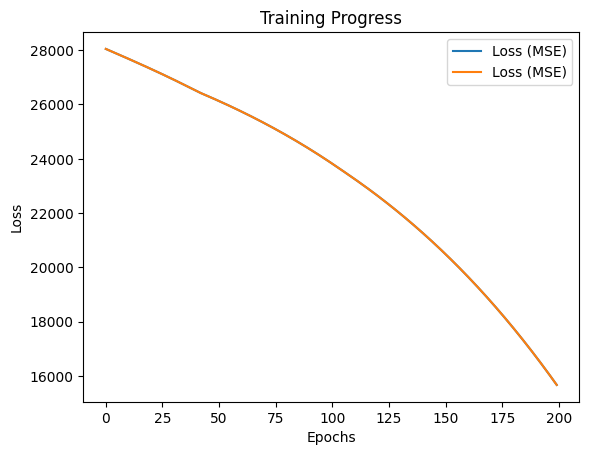

In [29]:
plt.plot(history.history['loss'],label='Loss (MSE)')
plt.plot(history.history['mae'],label='Loss (MSE)')
plt.title('Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [30]:
test_sample=np.array([[160,3550, 2.5]])
prediction=model.predict(test_sample)
print('Predicted price', prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted price 12138.403
